# Ethical AI Project — Module 2: Explainability System Design
**Dataset:** German Credit  
**Task:** Predict creditworthiness  
**Objective:** Build an interpretable ML system and analyze how and why it makes decisions.

In [1]:
# ============================================
# Ethical AI Project - Starter Notebook
# Dataset: German Credit
# Task: Predict creditworthiness
# ============================================

# -----------------------------
# 1. Install required libraries
# -----------------------------
!pip install pandas numpy scikit-learn matplotlib seaborn requests --quiet

import pandas as pd
import numpy as np
import requests
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Libraries installed and imported.")

# -----------------------------
# 2. Download dataset
# -----------------------------
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

data_path = data_dir / "german_credit_data.csv"
url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"

if not data_path.exists():
    print("Downloading German Credit dataset...")
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with open(data_path, "wb") as f:
        f.write(r.content)
    print("Download complete.")
else:
    print("Dataset already exists.")

# -----------------------------
# 3. Load dataset
# -----------------------------
df = pd.read_csv(data_path)

print("\nDataset loaded successfully")
print("Shape:", df.shape)

print("\nFirst rows:")
print(df.head())

print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isna().sum())

# -----------------------------
# 4. Standardize column names
# -----------------------------
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("\nStandardized columns:")
print(df.columns)

# -----------------------------
# 5. Identify target variable robustly
# -----------------------------
possible_targets = ["credit_risk", "class", "risk", "target"]

target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError(f"Could not find target column. Tried: {possible_targets}")

print("\nDetected target column:", target_col)
print("Raw target unique values:", df[target_col].unique())

# Handle common target formats robustly
if df[target_col].dtype == "object":
    cleaned = df[target_col].astype(str).str.strip().str.lower()

    # Case 1: already encoded as strings "0"/"1"
    if set(cleaned.unique()).issubset({"0", "1"}):
        df[target_col] = cleaned.astype(int)

    # Case 2: text labels
    elif set(cleaned.unique()).issubset({"good", "bad"}):
        df[target_col] = cleaned.map({"good": 1, "bad": 0})

    else:
        raise ValueError(
            f"Unsupported target values in {target_col}: {sorted(cleaned.unique())}"
        )
else:
    # numeric target
    df[target_col] = df[target_col].astype(int)

if df[target_col].isna().any():
    raise ValueError("Target column contains NaN after conversion.")

print("\nTarget distribution:")
print(df[target_col].value_counts(dropna=False))

# -----------------------------
# 6. Create cleaner protected attributes
# -----------------------------
# Extract binary sex from personal_status_sex
if "personal_status_sex" in df.columns:
    df["sex"] = df["personal_status_sex"].apply(
        lambda x: "female" if "female" in str(x).lower() else "male"
    )

# Common fairness grouping for age
if "age" in df.columns:
    df["age_group"] = np.where(df["age"] >= 25, "age_25_and_over", "under_25")

print("\nProtected attributes available:")
for col in ["sex", "age", "age_group"]:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].value_counts())

# -----------------------------
# 7. Split dataset
# -----------------------------
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test split")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("y_test distribution:")
print(y_test.value_counts())

# -----------------------------
# 8. Basic preprocessing pipeline
# -----------------------------
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nProcessed training matrix shape:", X_train_processed.shape)
print("Processed test matrix shape:", X_test_processed.shape)

# Optional: keep protected attributes aside for later fairness analysis
protected_cols = [c for c in ["sex", "age", "age_group"] if c in X_train.columns]
A_train = X_train[protected_cols].copy() if protected_cols else pd.DataFrame(index=X_train.index)
A_test = X_test[protected_cols].copy() if protected_cols else pd.DataFrame(index=X_test.index)

print("\nProtected attribute preview:")
print(A_train.head())

print("\nGerman Credit dataset ready for modeling.")


[notice] A new release of pip is available: 23.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\Adam\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries installed and imported.


Download complete.

Dataset loaded successfully
Shape: (1000, 21)

First rows:
                status  duration                            credit_history  \
0         ... < 100 DM         6   critical account/other credits existing   
1    0 <= ... < 200 DM        48  existing credits paid back duly till now   
2  no checking account        12   critical account/other credits existing   
3         ... < 100 DM        42  existing credits paid back duly till now   
4         ... < 100 DM        24           delay in paying off in the past   

               purpose  amount                     savings  \
0  domestic appliances    1169  unknown/no savings account   
1  domestic appliances    5951                ... < 100 DM   
2           retraining    2096                ... < 100 DM   
3     radio/television    7882                ... < 100 DM   
4            car (new)    4870                ... < 100 DM   

  employment_duration  installment_rate                  personal_status_sex  \

In [2]:
# ============================================
# Retrieve feature names after preprocessing
# ============================================
import scipy.sparse

# Get feature names from the preprocessor
num_feature_names = numeric_features
cat_feature_names = list(
    preprocessor.named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_features)
)
all_feature_names = num_feature_names + cat_feature_names

print(f"Total features after preprocessing: {len(all_feature_names)}")
print("\nFeature names:")
for i, name in enumerate(all_feature_names):
    print(f"  {i}: {name}")

# Convert sparse matrices to dense for tree-based models
if scipy.sparse.issparse(X_train_processed):
    X_train_dense = X_train_processed.toarray()
else:
    X_train_dense = np.array(X_train_processed)

if scipy.sparse.issparse(X_test_processed):
    X_test_dense = X_test_processed.toarray()
else:
    X_test_dense = np.array(X_test_processed)

Total features after preprocessing: 65

Feature names:
  0: duration
  1: amount
  2: installment_rate
  3: present_residence
  4: age
  5: number_credits
  6: people_liable
  7: status_... < 100 DM
  8: status_... >= 200 DM / salary for at least 1 year
  9: status_0 <= ... < 200 DM
  10: status_no checking account
  11: credit_history_all credits at this bank paid back duly
  12: credit_history_critical account/other credits existing
  13: credit_history_delay in paying off in the past
  14: credit_history_existing credits paid back duly till now
  15: credit_history_no credits taken/all credits paid back duly
  16: purpose_business
  17: purpose_car (new)
  18: purpose_car (used)
  19: purpose_domestic appliances
  20: purpose_education
  21: purpose_furniture/equipment
  22: purpose_others
  23: purpose_radio/television
  24: purpose_repairs
  25: purpose_retraining
  26: savings_... < 100 DM
  27: savings_... >= 1000 DM
  28: savings_100 <= ... < 500 DM
  29: savings_500 <= ... < 1

---
## Part 1: Model Training
Train an interpretable model: **Decision Tree** with `max_depth=5`.

In [3]:
# ============================================
# Part 1: Train a Decision Tree Classifier
# ============================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_dense, y_train)
y_pred = dt_model.predict(X_test_dense)

# --- Table 1: Performance Metrics ---
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("TABLE 1: Decision Tree Performance Metrics")
print("=" * 50)
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print("=" * 50)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Bad Credit (0)", "Good Credit (1)"]))

print(f"\nTree depth used: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")
print(f"Number of features actually used: {np.sum(dt_model.feature_importances_ > 0)}")

TABLE 1: Decision Tree Performance Metrics
  Accuracy:  0.6850
  Precision: 0.7251
  Recall:    0.8857
  F1-Score:  0.7974

Detailed Classification Report:
                 precision    recall  f1-score   support

 Bad Credit (0)       0.45      0.22      0.29        60
Good Credit (1)       0.73      0.89      0.80       140

       accuracy                           0.69       200
      macro avg       0.59      0.55      0.54       200
   weighted avg       0.64      0.69      0.65       200


Tree depth used: 5
Number of leaves: 28
Number of features actually used: 21


---
## Part 3: What Features Matter the Most?
Identify the most important features using `feature_importances_` from the Decision Tree.

TABLE 2: Top 10 Most Important Features
   1. status_no checking account               0.3109
   2. duration                                 0.1760
   3. amount                                   0.1014
   4. other_debtors_guarantor                  0.0566
   5. savings_unknown/no savings account       0.0540
   6. other_installment_plans_none             0.0386
   7. purpose_car (used)                       0.0326
   8. property_real estate                     0.0251
   9. age                                      0.0243
  10. credit_history_critical account/other credits existing 0.0241


C:\Users\Adam\AppData\Local\Temp\ipykernel_33676\2661742300.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis', ax=ax)


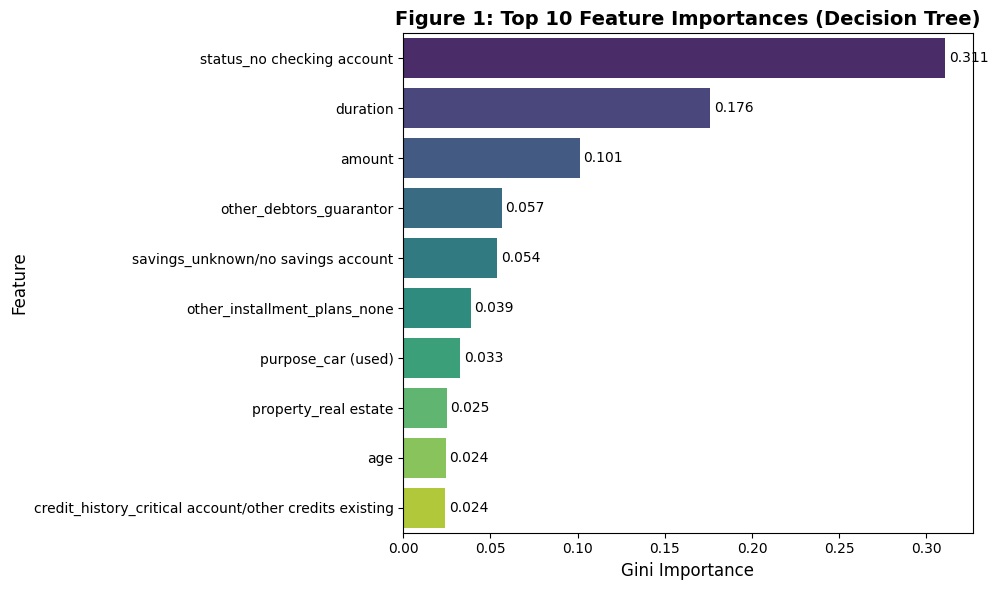


Features with zero importance: 44 out of 65
Features actually used by the tree: 21


In [4]:
# ============================================
# Part 3: Feature Importance Analysis
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances
importances = dt_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# --- Table 2: Top 10 Most Important Features ---
top_n = 10
top_features = feat_imp_df.head(top_n)

print("=" * 55)
print("TABLE 2: Top 10 Most Important Features")
print("=" * 55)
for i, row in enumerate(top_features.itertuples(), 1):
    print(f"  {i:2d}. {row.Feature:<40s} {row.Importance:.4f}")
print("=" * 55)

# --- Figure 1: Feature Importance Bar Chart ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title('Figure 1: Top 10 Feature Importances (Decision Tree)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gini Importance', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
for i, v in enumerate(top_features['Importance']):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Count features with zero importance
zero_imp = (importances == 0).sum()
print(f"\nFeatures with zero importance: {zero_imp} out of {len(all_feature_names)}")
print(f"Features actually used by the tree: {len(all_feature_names) - zero_imp}")

---
## Part 4: How Do Features Affect Predictions?
Analyze direction and behavior of key features through tree splits and visualization.

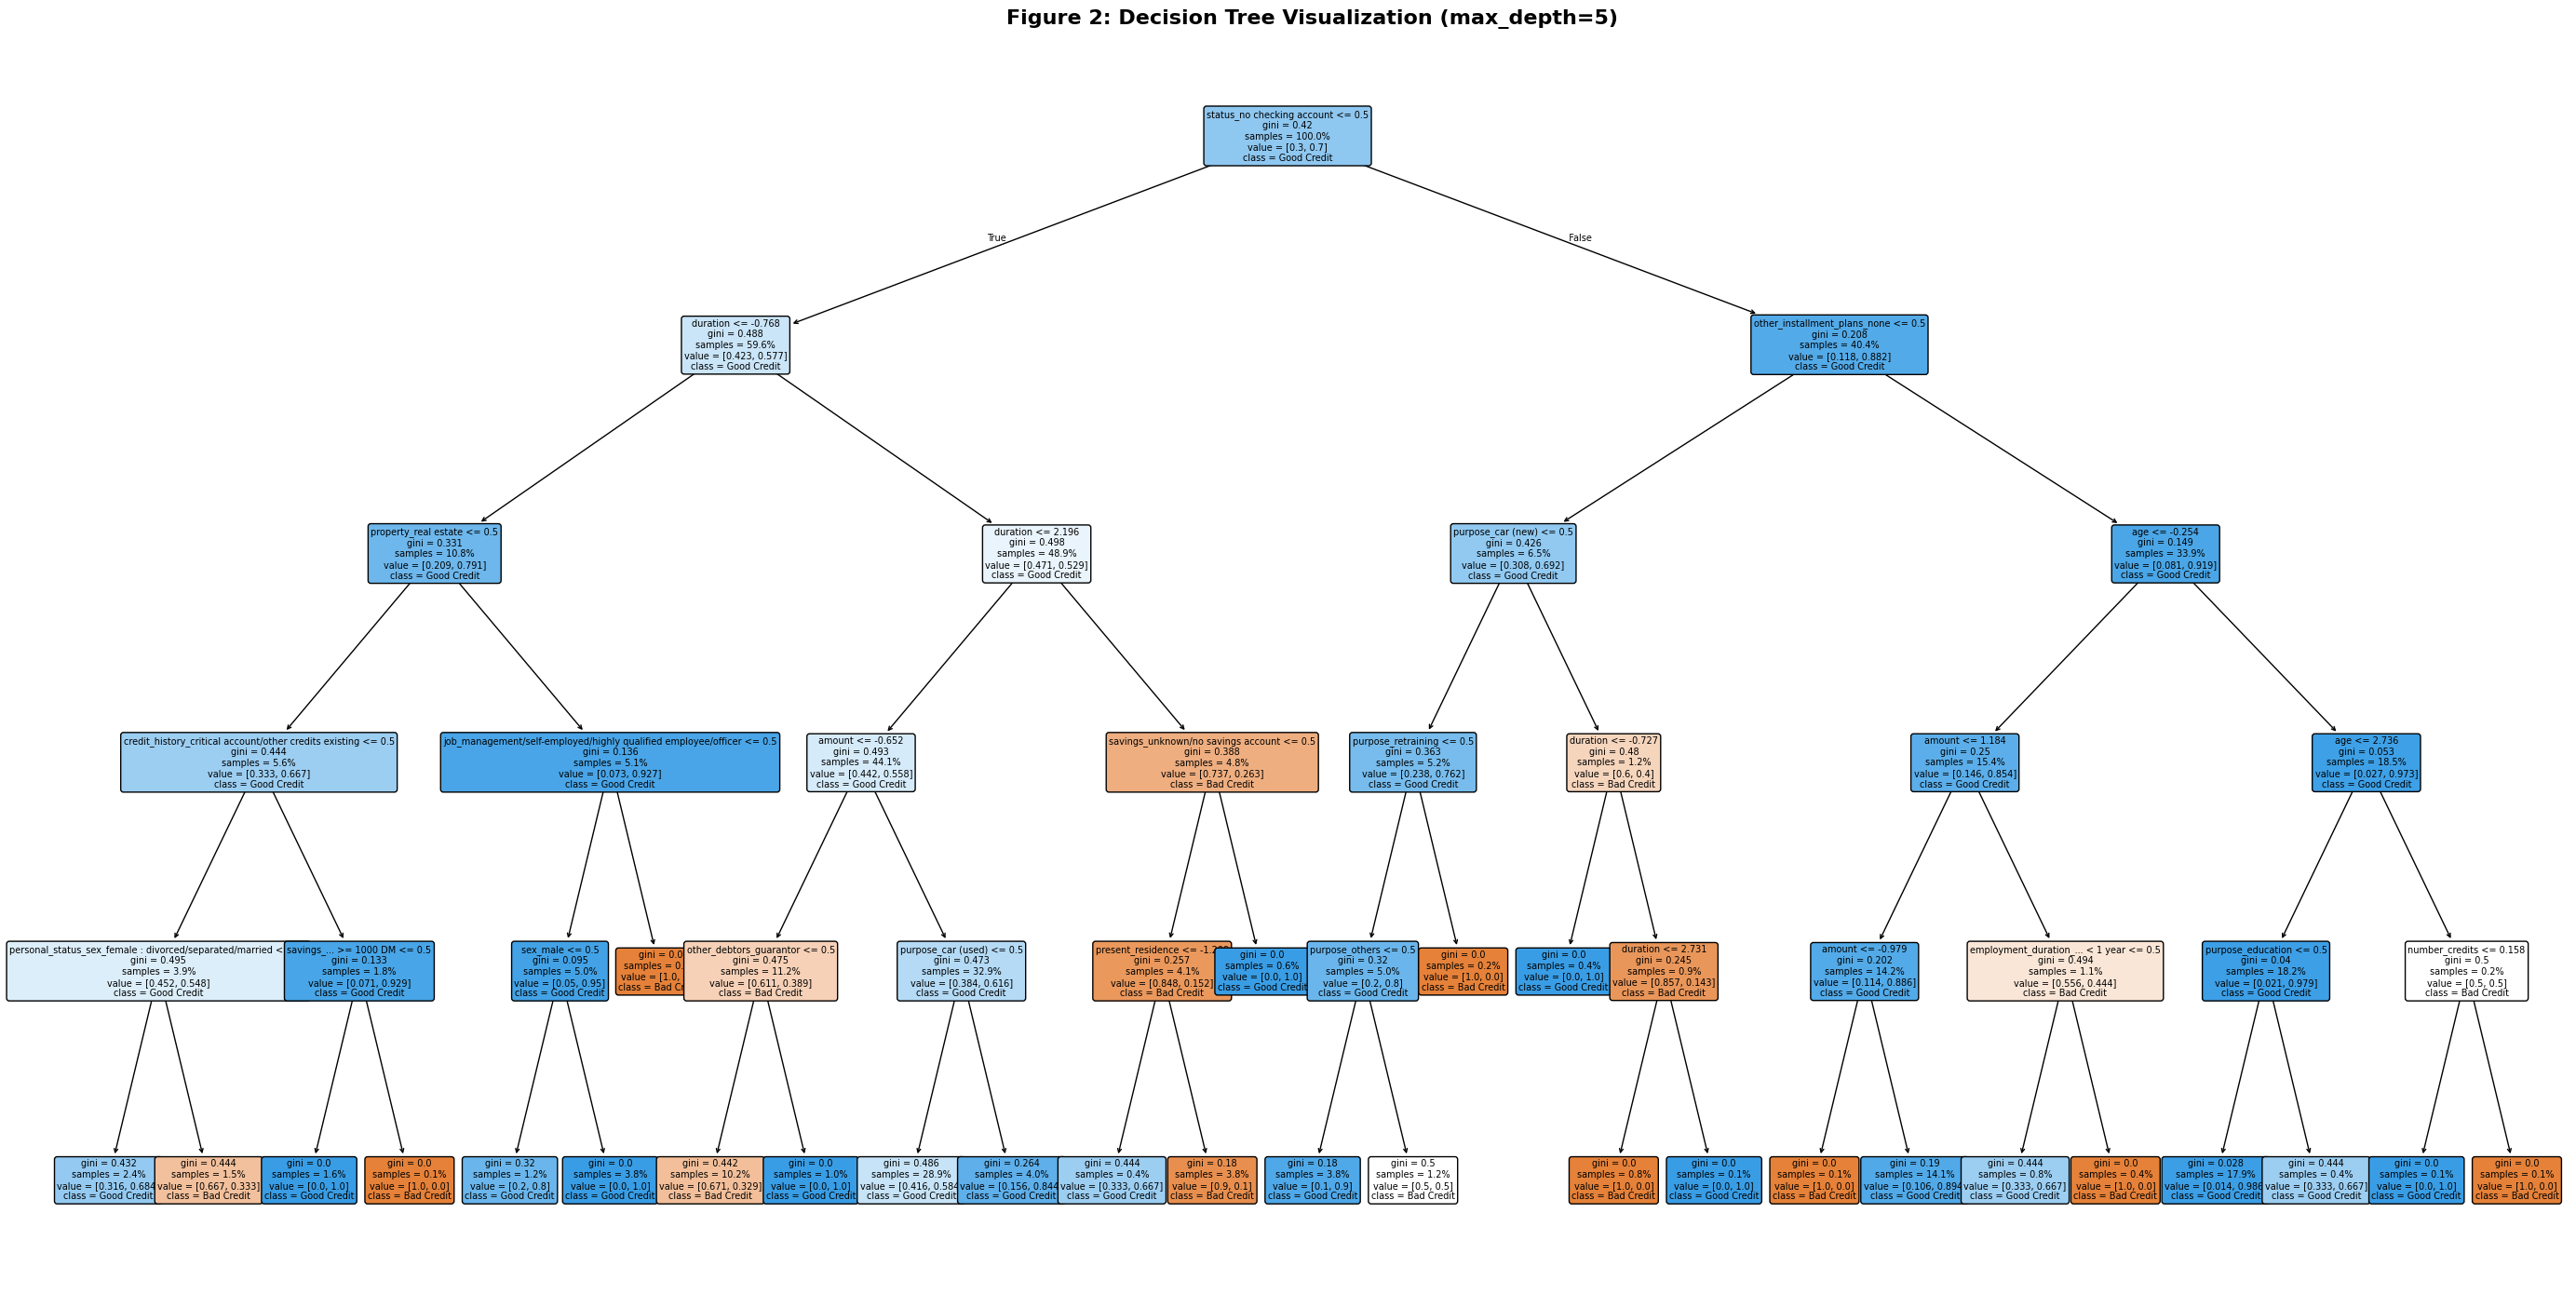


Decision Tree Rules (Text):
|--- status_no checking account <= 0.50
|   |--- duration <= -0.77
|   |   |--- property_real estate <= 0.50
|   |   |   |--- credit_history_critical account/other credits existing <= 0.50
|   |   |   |   |--- personal_status_sex_female : divorced/separated/married <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- personal_status_sex_female : divorced/separated/married >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- credit_history_critical account/other credits existing >  0.50
|   |   |   |   |--- savings_... >= 1000 DM <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- savings_... >= 1000 DM >  0.50
|   |   |   |   |   |--- class: 0
|   |   |--- property_real estate >  0.50
|   |   |   |--- job_management/self-employed/highly qualified employee/officer <= 0.50
|   |   |   |   |--- sex_male <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- sex_male >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- j

In [5]:
# ============================================
# Part 4: Tree Visualization & Split Analysis
# ============================================
from sklearn.tree import export_text, plot_tree

# --- Figure 2: Full Decision Tree Visualization ---
fig, ax = plt.subplots(figsize=(28, 14))
plot_tree(
    dt_model,
    feature_names=all_feature_names,
    class_names=['Bad Credit', 'Good Credit'],
    filled=True,
    rounded=True,
    fontsize=7,
    proportion=True,
    ax=ax
)
ax.set_title('Figure 2: Decision Tree Visualization (max_depth=5)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Text representation of the tree ---
print("\nDecision Tree Rules (Text):")
print("=" * 60)
tree_rules = export_text(dt_model, feature_names=all_feature_names, max_depth=5)
print(tree_rules)

TABLE 3: Decision Tree Split Analysis — Feature Effects
Feature                                   Threshold Direction of Effect
-----------------------------------------------------------------
  status_no checking account                   0.50   > 0.50 favors Good Credit
  duration                                    -0.77   <= -0.77 favors Good Credit
  property_real estate                         0.50   > 0.50 favors Good Credit
  credit_history_critical account/other credits existing       0.50   > 0.50 favors Good Credit
  personal_status_sex_female : divorced/separated/married       0.50   <= 0.50 favors Good Credit
  savings_... >= 1000 DM                       0.50   <= 0.50 favors Good Credit
  job_management/self-employed/highly qualified employee/officer       0.50   <= 0.50 favors Good Credit
  sex_male                                     0.50   > 0.50 favors Good Credit
  amount                                      -0.65   > -0.65 favors Good Credit
  other_debtors_guarant

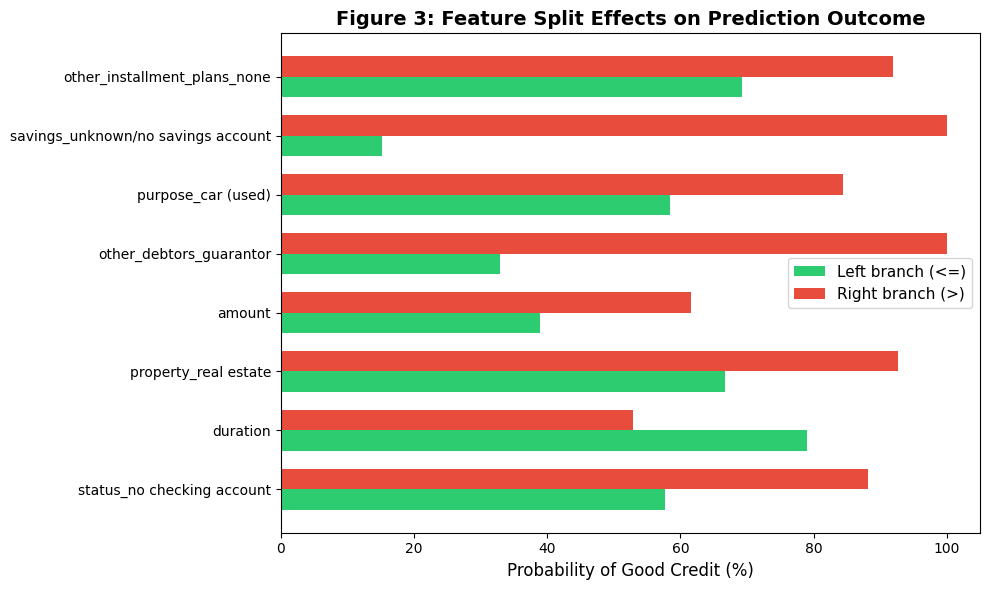

In [6]:
# ============================================
# Part 4 (continued): Split Threshold Analysis
# ============================================

# Extract split information from the tree
tree = dt_model.tree_

print("=" * 65)
print("TABLE 3: Decision Tree Split Analysis — Feature Effects")
print("=" * 65)
print(f"{'Feature':<40s} {'Threshold':>10s} {'Direction of Effect'}")
print("-" * 65)

visited_features = set()
for node_id in range(tree.node_count):
    if tree.children_left[node_id] != tree.children_right[node_id]:  # not a leaf
        feat_idx = tree.feature[node_id]
        threshold = tree.threshold[node_id]
        feat_name = all_feature_names[feat_idx]
        
        # Analyze: which direction leads to more "Good Credit"?
        left_child = tree.children_left[node_id]
        right_child = tree.children_right[node_id]
        
        # Class 1 (Good Credit) proportion in left vs right
        left_good_ratio = tree.value[left_child][0][1] / tree.value[left_child][0].sum()
        right_good_ratio = tree.value[right_child][0][1] / tree.value[right_child][0].sum()
        
        if feat_name not in visited_features:
            if left_good_ratio > right_good_ratio:
                direction = f"<= {threshold:.2f} favors Good Credit"
            else:
                direction = f"> {threshold:.2f} favors Good Credit"
            
            print(f"  {feat_name:<38s} {threshold:>10.2f}   {direction}")
            visited_features.add(feat_name)

print("=" * 65)

# --- Figure 3: Feature Effect Direction Summary ---
# For each top feature, show how split direction affects outcome
top_feat_names = top_features['Feature'].tolist()[:8]
effect_data = []

for node_id in range(tree.node_count):
    if tree.children_left[node_id] != tree.children_right[node_id]:
        feat_idx = tree.feature[node_id]
        feat_name = all_feature_names[feat_idx]
        if feat_name in top_feat_names:
            threshold = tree.threshold[node_id]
            left_child = tree.children_left[node_id]
            right_child = tree.children_right[node_id]
            left_good = tree.value[left_child][0][1] / tree.value[left_child][0].sum()
            right_good = tree.value[right_child][0][1] / tree.value[right_child][0].sum()
            n_samples = tree.n_node_samples[node_id]
            effect_data.append({
                'Feature': feat_name,
                'Threshold': threshold,
                'Left (<=) Good%': left_good * 100,
                'Right (>) Good%': right_good * 100,
                'Samples': n_samples
            })

effect_df = pd.DataFrame(effect_data)
# Keep first occurrence per feature for clarity
effect_df = effect_df.drop_duplicates(subset='Feature', keep='first')

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(effect_df))
width = 0.35
ax.barh(x - width/2, effect_df['Left (<=) Good%'], width, label='Left branch (<=)', color='#2ecc71')
ax.barh(x + width/2, effect_df['Right (>) Good%'], width, label='Right branch (>)', color='#e74c3c')
ax.set_yticks(x)
ax.set_yticklabels(effect_df['Feature'], fontsize=10)
ax.set_xlabel('Probability of Good Credit (%)', fontsize=12)
ax.set_title('Figure 3: Feature Split Effects on Prediction Outcome', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('feature_effects.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 5: Local Explanations (2 Individuals)
Pick two individuals and trace the decision path to explain each prediction.

In [7]:
# ============================================
# Part 5: Local Explanations for 2 Individuals
# ============================================

def explain_individual(model, X_data, feature_names, individual_idx, X_original, y_true, label="Individual"):
    """
    Trace the decision path for one individual through the tree
    and explain the prediction step by step.
    """
    sample = X_data[individual_idx].reshape(1, -1)
    prediction = model.predict(sample)[0]
    proba = model.predict_proba(sample)[0]
    actual = y_true.iloc[individual_idx]
    
    print("=" * 60)
    print(f"{label}")
    print("=" * 60)
    print(f"  Predicted class: {'Good Credit (1)' if prediction == 1 else 'Bad Credit (0)'}")
    print(f"  Actual class:    {'Good Credit (1)' if actual == 1 else 'Bad Credit (0)'}")
    print(f"  Confidence:      Bad={proba[0]:.3f}, Good={proba[1]:.3f}")
    print(f"  Correct:         {'Yes' if prediction == actual else 'No'}")
    
    # Show original (unprocessed) feature values
    original_row = X_original.iloc[individual_idx]
    print(f"\n  Original feature values:")
    for col in ['age', 'sex', 'age_group', 'duration', 'amount', 'credit_amount']:
        if col in original_row.index:
            print(f"    {col}: {original_row[col]}")
    
    # Trace decision path
    tree = model.tree_
    node_indicator = model.decision_path(sample)
    node_indices = node_indicator.indices
    
    print(f"\n  Decision path (depth={len(node_indices)-1} nodes):")
    print("  " + "-" * 56)
    
    for i, node_id in enumerate(node_indices):
        if tree.children_left[node_id] == tree.children_right[node_id]:
            # Leaf node
            class_counts = tree.value[node_id][0]
            total = class_counts.sum()
            print(f"  Step {i+1}: LEAF -> class={'Good' if class_counts[1] > class_counts[0] else 'Bad'} "
                  f"(Bad={class_counts[0]/total:.1%}, Good={class_counts[1]/total:.1%})")
        else:
            feat_idx = tree.feature[node_id]
            threshold = tree.threshold[node_id]
            feat_name = feature_names[feat_idx]
            feat_value = sample[0, feat_idx]
            direction = "<=" if feat_value <= threshold else ">"
            branch = "LEFT" if feat_value <= threshold else "RIGHT"
            print(f"  Step {i+1}: {feat_name} = {feat_value:.3f} {direction} {threshold:.3f} -> go {branch}")
    
    print("=" * 60)
    return prediction, actual


# --- Select 2 individuals: one Good Credit, one Bad Credit ---
# Find one correctly classified Good Credit
good_mask = (y_test.values == 1) & (y_pred == 1)
good_indices = np.where(good_mask)[0]
individual_1_idx = good_indices[0] if len(good_indices) > 0 else 0

# Find one correctly classified Bad Credit
bad_mask = (y_test.values == 0) & (y_pred == 0)
bad_indices = np.where(bad_mask)[0]
individual_2_idx = bad_indices[0] if len(bad_indices) > 0 else 1

print("LOCAL EXPLANATIONS FOR TWO INDIVIDUALS")
print()

pred1, act1 = explain_individual(
    dt_model, X_test_dense, all_feature_names,
    individual_1_idx, X_test, y_test,
    label="INDIVIDUAL 1 (Approved — Good Credit)"
)

print()

pred2, act2 = explain_individual(
    dt_model, X_test_dense, all_feature_names,
    individual_2_idx, X_test, y_test,
    label="INDIVIDUAL 2 (Denied — Bad Credit)"
)

LOCAL EXPLANATIONS FOR TWO INDIVIDUALS

INDIVIDUAL 1 (Approved — Good Credit)
  Predicted class: Good Credit (1)
  Actual class:    Good Credit (1)
  Confidence:      Bad=0.416, Good=0.584
  Correct:         Yes

  Original feature values:
    age: 42
    sex: male
    age_group: age_25_and_over
    duration: 18
    amount: 2427

  Decision path (depth=5 nodes):
  --------------------------------------------------------
  Step 1: status_no checking account = 0.000 <= 0.500 -> go LEFT
  Step 2: duration = -0.233 > -0.768 -> go RIGHT
  Step 3: duration = -0.233 <= 2.196 -> go LEFT
  Step 4: amount = -0.274 > -0.652 -> go RIGHT
  Step 5: purpose_car (used) = 0.000 <= 0.500 -> go LEFT
  Step 6: LEAF -> class=Good (Bad=41.6%, Good=58.4%)

INDIVIDUAL 2 (Denied — Bad Credit)
  Predicted class: Bad Credit (0)
  Actual class:    Bad Credit (0)
  Confidence:      Bad=0.671, Good=0.329
  Correct:         Yes

  Original feature values:
    age: 33
    sex: male
    age_group: age_25_and_over
    

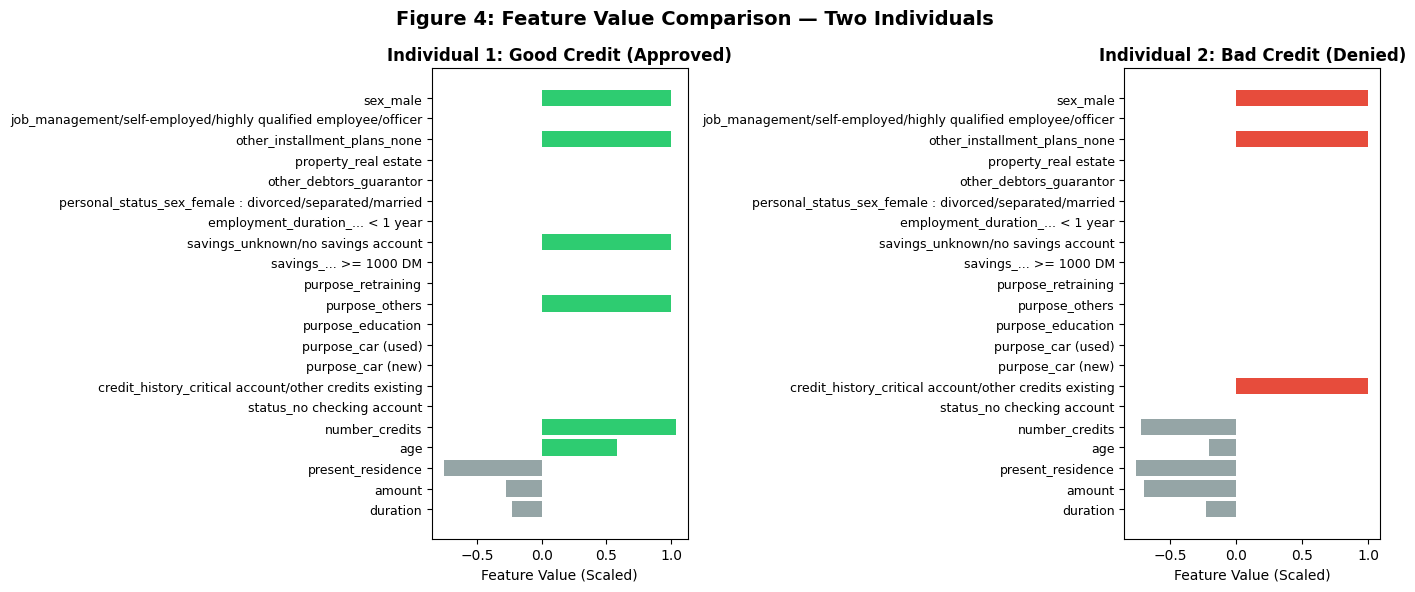

In [8]:
# ============================================
# Part 5 (continued): Visual comparison of the two individuals
# ============================================

# Get the features used in the tree for both individuals
used_feature_indices = np.where(dt_model.feature_importances_ > 0)[0]
used_feature_names = [all_feature_names[i] for i in used_feature_indices]

ind1_values = X_test_dense[individual_1_idx, used_feature_indices]
ind2_values = X_test_dense[individual_2_idx, used_feature_indices]

# --- Figure 4: Side-by-side comparison of the two individuals ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Individual 1
colors1 = ['#2ecc71' if v > 0 else '#95a5a6' for v in ind1_values]
axes[0].barh(range(len(used_feature_names)), ind1_values, color=colors1)
axes[0].set_yticks(range(len(used_feature_names)))
axes[0].set_yticklabels(used_feature_names, fontsize=9)
axes[0].set_title('Individual 1: Good Credit (Approved)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature Value (Scaled)')

# Individual 2
colors2 = ['#e74c3c' if v > 0 else '#95a5a6' for v in ind2_values]
axes[1].barh(range(len(used_feature_names)), ind2_values, color=colors2)
axes[1].set_yticks(range(len(used_feature_names)))
axes[1].set_yticklabels(used_feature_names, fontsize=9)
axes[1].set_title('Individual 2: Bad Credit (Denied)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature Value (Scaled)')

plt.suptitle('Figure 4: Feature Value Comparison — Two Individuals', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('individual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 6: Detect Suspicious Patterns
Identify questionable, unexpected, or unfair patterns in the model.

In [9]:
# ============================================
# Part 6: Suspicious Pattern Detection
# ============================================

print("=" * 60)
print("SUSPICIOUS PATTERN ANALYSIS")
print("=" * 60)

# --- Check 1: Are protected attributes used or proxied? ---
print("\n[Check 1] Protected attribute usage in the tree:")
print("-" * 60)
protected_keywords = ['sex', 'age', 'age_group', 'personal_status', 'foreign_worker']
for feat_name, imp in zip(all_feature_names, importances):
    if imp > 0:
        for keyword in protected_keywords:
            if keyword in feat_name.lower():
                print(f"  WARNING: '{feat_name}' (importance={imp:.4f}) is related to protected attribute '{keyword}'")

# --- Check 2: Prediction rates by demographic group ---
print("\n[Check 2] Prediction rates by demographic group:")
print("-" * 60)

for attr in ['age_group', 'sex']:
    if attr in A_test.columns:
        print(f"\n  Protected attribute: {attr}")
        groups = A_test[attr].unique()
        for group in sorted(groups):
            mask = A_test[attr].values == group
            pred_rate = np.mean(y_pred[mask])
            actual_rate = np.mean(y_test.values[mask])
            err_rate = 1 - accuracy_score(y_test.values[mask], y_pred[mask])
            n = mask.sum()
            print(f"    {group:>20s}: pred_rate={pred_rate:.3f}, actual_rate={actual_rate:.3f}, "
                  f"error_rate={err_rate:.3f}, n={n}")

# --- Check 3: Feature importance of sensitive features ---
print("\n[Check 3] Importance of sensitive/proxy features:")
print("-" * 60)
sensitive_features = [f for f in all_feature_names if any(
    kw in f.lower() for kw in ['sex', 'age', 'foreign', 'personal_status']
)]
total_sensitive_importance = 0
for feat in sensitive_features:
    idx = all_feature_names.index(feat)
    imp = importances[idx]
    if imp > 0:
        print(f"  {feat}: importance = {imp:.4f}")
        total_sensitive_importance += imp

if total_sensitive_importance == 0:
    print("  No sensitive features directly used by the tree.")
else:
    print(f"\n  Total importance from sensitive features: {total_sensitive_importance:.4f} "
          f"({total_sensitive_importance/sum(importances)*100:.1f}% of total)")

SUSPICIOUS PATTERN ANALYSIS

[Check 1] Protected attribute usage in the tree:
------------------------------------------------------------

[Check 2] Prediction rates by demographic group:
------------------------------------------------------------

  Protected attribute: age_group
         age_25_and_over: pred_rate=0.866, actual_rate=0.721, error_rate=0.285, n=172
                under_25: pred_rate=0.786, actual_rate=0.571, error_rate=0.500, n=28

  Protected attribute: sex
                  female: pred_rate=0.750, actual_rate=0.667, error_rate=0.383, n=60
                    male: pred_rate=0.900, actual_rate=0.714, error_rate=0.286, n=140

[Check 3] Importance of sensitive/proxy features:
------------------------------------------------------------
  age: importance = 0.0243
  personal_status_sex_female : divorced/separated/married: importance = 0.0156
  job_management/self-employed/highly qualified employee/officer: importance = 0.0152
  sex_male: importance = 0.0052

  Total i

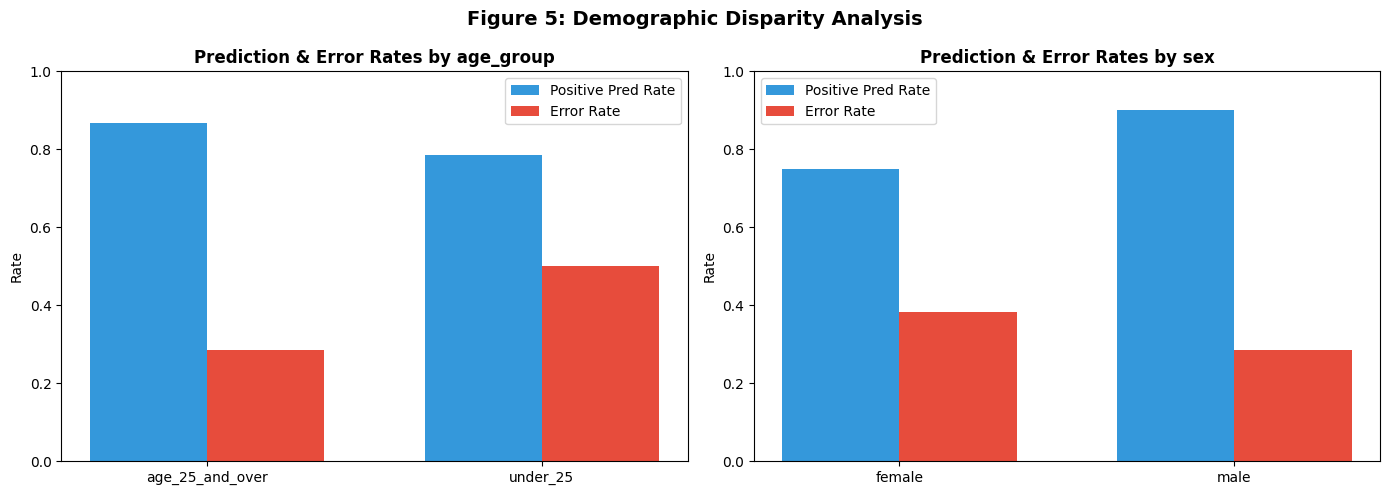

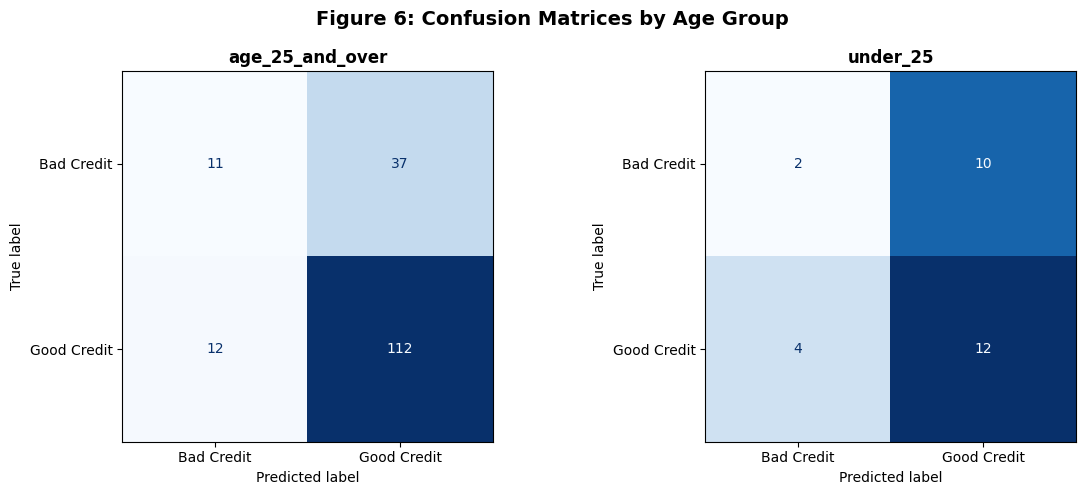

In [10]:
# ============================================
# Part 6 (continued): Visualize disparities
# ============================================

# --- Figure 5: Prediction and error rates by Age Group ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, attr in enumerate(['age_group', 'sex']):
    if attr not in A_test.columns:
        continue
    groups = sorted(A_test[attr].unique())
    pred_rates = []
    err_rates = []
    for group in groups:
        mask = A_test[attr].values == group
        pred_rates.append(np.mean(y_pred[mask]))
        err_rates.append(1 - accuracy_score(y_test.values[mask], y_pred[mask]))
    
    x = np.arange(len(groups))
    width = 0.35
    axes[ax_idx].bar(x - width/2, pred_rates, width, label='Positive Pred Rate', color='#3498db')
    axes[ax_idx].bar(x + width/2, err_rates, width, label='Error Rate', color='#e74c3c')
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(groups, fontsize=10)
    axes[ax_idx].set_ylabel('Rate')
    axes[ax_idx].set_title(f'Prediction & Error Rates by {attr}', fontsize=12, fontweight='bold')
    axes[ax_idx].legend()
    axes[ax_idx].set_ylim(0, 1)

plt.suptitle('Figure 5: Demographic Disparity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('disparity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 6: Confusion matrix by group ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax_idx, group in enumerate(sorted(A_test['age_group'].unique())):
    mask = A_test['age_group'].values == group
    cm = confusion_matrix(y_test.values[mask], y_pred[mask])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Bad Credit', 'Good Credit'])
    disp.plot(ax=axes[ax_idx], cmap='Blues', colorbar=False)
    axes[ax_idx].set_title(f'{group}', fontsize=12, fontweight='bold')

plt.suptitle('Figure 6: Confusion Matrices by Age Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ============================================
# Part 6 (continued): Correlation between
# protected attributes and top features
# ============================================

print("\n[Check 4] Proxy detection — correlation between top features and protected attributes:")
print("-" * 60)

# Create a dataframe with processed features
test_df = pd.DataFrame(X_test_dense, columns=all_feature_names)

# Encode age_group and sex as numeric for correlation
test_df['age_group_numeric'] = (A_test['age_group'].values == 'age_25_and_over').astype(int)
if 'sex' in A_test.columns:
    test_df['sex_numeric'] = (A_test['sex'].values == 'male').astype(int)

# Compute correlations of top features with protected attributes
top_feature_list = top_features['Feature'].tolist()[:10]

print(f"\n  {'Feature':<40s} {'Corr w/ Age':>12s}  {'Corr w/ Sex':>12s}")
print("  " + "-" * 66)

for feat in top_feature_list:
    corr_age = np.corrcoef(test_df[feat], test_df['age_group_numeric'])[0, 1]
    if 'sex_numeric' in test_df.columns:
        corr_sex = np.corrcoef(test_df[feat], test_df['sex_numeric'])[0, 1]
    else:
        corr_sex = float('nan')
    
    flag = "" 
    if abs(corr_age) > 0.3 or abs(corr_sex) > 0.3:
        flag = " <-- POTENTIAL PROXY"
    
    print(f"  {feat:<40s} {corr_age:>12.3f}  {corr_sex:>12.3f}{flag}")

print("\n  Note: |correlation| > 0.3 flagged as potential proxy for protected attribute.")


[Check 4] Proxy detection — correlation between top features and protected attributes:
------------------------------------------------------------

  Feature                                   Corr w/ Age   Corr w/ Sex
  ------------------------------------------------------------------
  status_no checking account                      0.119         0.052
  duration                                       -0.056        -0.003
  amount                                         -0.013        -0.082
  other_debtors_guarantor                        -0.029         0.110
  savings_unknown/no savings account              0.068         0.093
  other_installment_plans_none                   -0.062        -0.035
  purpose_car (used)                             -0.097        -0.132
  property_real estate                           -0.105         0.068
  age                                             0.485         0.079 <-- POTENTIAL PROXY
  credit_history_critical account/other credits existing     

---
## Part 7: Design Recommendation
Evaluation of this system as if deploying it in the real world.

In [12]:
# ============================================
# Part 7: Summary Dashboard
# ============================================

print("=" * 60)
print("MODULE 2 — FINAL SUMMARY")
print("=" * 60)

print(f"\n  Model: Decision Tree (max_depth=5)")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print(f"\n  Tree depth: {dt_model.get_depth()}")
print(f"  Leaves: {dt_model.get_n_leaves()}")
print(f"  Features used: {np.sum(dt_model.feature_importances_ > 0)} / {len(all_feature_names)}")

print(f"\n  Top 3 features:")
for i, row in enumerate(feat_imp_df.head(3).itertuples(), 1):
    print(f"    {i}. {row.Feature} ({row.Importance:.4f})")

print(f"\n  Sensitive feature usage: ", end="")
if total_sensitive_importance > 0:
    print(f"YES — {total_sensitive_importance:.4f} total importance")
else:
    print("NONE directly used")

print("\n  Figures saved:")
for fig_file in ['feature_importance.png', 'decision_tree.png', 'feature_effects.png',
                 'individual_comparison.png', 'disparity_analysis.png', 'confusion_by_group.png']:
    print(f"    - {fig_file}")

print("\n" + "=" * 60)

MODULE 2 — FINAL SUMMARY

  Model: Decision Tree (max_depth=5)
  Accuracy:  0.6850
  Precision: 0.7251
  Recall:    0.8857
  F1-Score:  0.7974

  Tree depth: 5
  Leaves: 28
  Features used: 21 / 65

  Top 3 features:
    1. status_no checking account (0.3109)
    2. duration (0.1760)
    3. amount (0.1014)

  Sensitive feature usage: YES — 0.0603 total importance

  Figures saved:
    - feature_importance.png
    - decision_tree.png
    - feature_effects.png
    - individual_comparison.png
    - disparity_analysis.png
    - confusion_by_group.png

